In [3]:
import scanpy as sc

adata = sc.read_h5ad('/home/Data_Drive_8TB_2/CRC_2026/KRAS_project/4.h5ad/MRTX_mouse_tumor_cell_subset_260401.h5ad')

adata_raw = adata.raw.to_adata().copy()

In [7]:
adata_raw.X.max()

3383

In [8]:
adata_raw.write('/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/adata_raw.h5ad')

In [9]:
adata.var

,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm
St18,1836,True,1888.0,0.031540,0.044444,1.233535
Rrs1,13404,True,1434.0,0.485632,0.966828,1.343889
Mybl1,4487,True,1229.0,0.145334,0.250142,1.426480
Prex2,134,True,1974.0,0.000919,0.001248,1.212764
Sulf1,213,True,1010.0,0.000165,0.000306,1.535803
...,...,...,...,...,...,...
Gm15155,83,True,605.0,0.002261,0.004706,1.872916
Map7d2,1201,True,1426.0,0.035945,0.055524,1.348730
Ppef1,5484,True,1339.0,0.186249,0.318666,1.383329
Gm47283,18102,True,1345.0,0.634616,1.411824,1.380089


In [11]:
KRAS_UP = [
'ETV1','SCN4A','E2F2','METTL1','NOP16','RRP12','MRTO4','RELT','WDR3','NAV3',
'TCOF1','ABCB11','DHRS9','GEMIN5','POLR3H','PROCR','NOP56','SERPINE1','CCDC86',
'BYSL','RASGRF2','RRP9','ODC1','FARSB','WDR77','SRM','RCL1','MTHFD1L','EGR1',
'UTP20','POLR1B','TOMM40','DUSP9','PRR7','AOC2','TNS4','NIP7','WDR74','NAT10',
'MYC','POLR1E','ADCY3','GPAT3','PHLDA1','DUSP6','UTP4','URB1','RGS16',
'SLC43A1','NEIL2','ANKRD61','DUSP2','MPZ','HK2','WDR4','WDR43','UTP15','NOL6',
'DDX21','TSR1','SLC19A1','CTU2','FOSL1','ETV4','EGR3','LCK','UPP1','CMSS1',
'EVI2B','SPRY4','NOC2L','YRDC','MAK16','SH2D1B','IQANK1','QTRT1','RSC1A1',
'ETV5','TMEM158','BOP1','PDE8B','DUSP4','VGF','ANKRD1','CSF2','FREM1','FOS',
'SHC4','SMOC1','MEF2B','EGR2','HMGA1','STAMBPL1','KIRREL3','HAS2','TDRD12',
'FOXL1','PRR22','DND1','MYBL2','IL27RA','NT5DC3','MYBBP1A','PADI3','PLA2G7',
'FGFR4','NLRP3','CHCHD4','CAMKV','NNMT','SEMA6B','SAC3D1','MFSD2A','HBA1',
'RUNX3','TBXAS1','FGF21','CCND1','EPHA2','CILP2','TTLL10','CALB2','SPRED2',
'AHRR','REEP1','PTGS2','TAF7L','DUSP5','SLC14A1','ESM1','TMEM200A','TAS1R3',
'APLN','SOX2','FAM78B','UBAP1L'
]


KRAS_down = ['ITGAL', 'SEMA3B', 'CALCOCO1', 'STAG3', 'FRY', 'TP53INP2', 'SESN1', 'HSD17B14', 'ASAP3', 'EBF4', 'DZANK1','SI', 'CDHR5', 'YPEL1', 'MAP1LC3A', 'BMF', 'CPQ', 'FCGRT', 'VSIR', 'SPOCK2', 'COL1A1', 'BST1', 'CRYAB',
                        'FOLR1', 'GABRR2', 'C1ORF54', 'TNFSF10', 'FMOD', 'MXD4', 'ZBP1', 'FGD3', 'SHC2', 'ACE2', 'ATP8B3', 
                        'SPINK5', 'AMPD3', 'WNT2B', 'AGO4', 'FHOD3', 'CAPN9', 'TMEM8B', 'THBS1', 'PDE5A', 'FBLN5', 'RORC', 
                        'TENM2', 'HMCN2', 'SYT8', 'PLCH2', 'CTF1', 'PDCD4', 'ENKUR', 'CCL28', 'PLA2R1', 'PID1', 'FBXO32', 'C1R',
                        'GBP2', 'GBP4', 'ACTG2', 'EFHB', 'IL15', 'TLR3', 'GPR146', 'ALDH1A1', 'PGM2L1', 'LDHD', 'PRRT2', 'PSCA', 
                        'GPT', 'THBS3', 'LAMB2', 'PDE3A', 'CNIH2', 'YPEL2', 'MAF', 'RRH', 'FZD2', 'C1S', 'NEB', 'CCDC159',
                        'SERHL2', 'KLHDC8B', 'SMTNL2', 'NOXO1', 'DNAH10', 'ATL1', 'SHISA4', 'H2AC18', 'GSTM2', 'TNFSF12', 
                        'UPK3B', 'SELENOP', 'SEMA3F', 'ALDH3B1', 'NTN4', 'IZUMO4', 'CD79A', 'PTGDS', 'CXCL6', 'PRPH', 'AGT',
                        'EMILIN1', 'CRABP2', 'SLC5A11', 'CCDC17', 'SYNC', 'MXRA8', 'PCBP3', 'COLEC10', 'H2AC15', 'TSPOAP1',
                        'PON1', 'GCKR', 'ACHE', 'SH2D3C', 'PIK3IP1', 'NCF4', 'RASSF2', 'RARRES2', 'ID3', 'IFIT3', 'IFIT2',
                        'CCDC170', 'TRIM6', 'LDB3', 'GNMT', 'AMOT', 'SYT11', 'GCC2', 'SCN2A', 'CASP1', 'ACVRL1', 'WDR93', 
                        'NECTIN4', 'SELENBP1', 'SLC22A14', 'SLC7A7', 'RHBDL2', 'SPON2', 'TNFRSF13C', 'GAB3', 'DHRS3', 'CTSS', 
                        'YPEL4', 'NAT1', 'SYNPO', 'SCUBE2', 'EXOC3L1', 'UBA7', 'MAFA', 'PROS1', 'STON1', 'CFB', 'CCDC187',
                        'IKZF2', 'DNAH5', 'ALPK1', 'RARB', 'CLIP3', 'DHX58', 'VWA5A', 'ACCS', 'PIK3R3', 'KCNJ2', 'C1QTNF6',
                        'C5AR2', 'WDR38', 'IFI44L', 'CBLN3', 'ZFP14', 'RBMS3', 'PRSS23', 'MR1', 'LCA5L', 'MRAS', 'TENT5B', 
                        'IFI16', 'TTC16', 'FILIP1L', 'ATOH8', 'STAT2', 'TLR1', 'CABP4', 'SSC5D', 'KBTBD3', 'POU6F1', 'LMNTD2', 
                        'IFIT1', 'APOD', 'SLC29A3', 'COLQ', 'PATL2', 'SMIM1', 'CTSO', 'TXNIP', 'H2BC7', 'MYO16', 'PDGFRB',
                        'ALDH6A1', 'DENND2A', 'ANK3', 'LRRIQ3', 'FAM227B', 'PTPRCAP', 'CCN5', 'SLC4A4', 'SPDEF', 'PLCE1',
                        'FGD2', 'DOCK11', 'SPTA1', 'PLA2G4F', 'DLK2', 'CEP290', 'DIO2', 'VSTM5']


In [17]:
from mygene import MyGeneInfo
import pandas as pd

mg = MyGeneInfo()

human_up = KRAS_UP
human_down = KRAS_down
human_genes = list(set(human_up + human_down))

df = mg.querymany(
    human_genes,
    scopes="symbol",
    fields=["homologene", "symbol"],
    species="human",
    as_dataframe=True,
)

if "notfound" not in df.columns:
    df["notfound"] = False
else:
    df["notfound"] = df["notfound"].fillna(False).astype(bool)

if "homologene.genes" not in df.columns:
    raise ValueError("homologene.genes column 없음")

df = df[~df["notfound"]]

exploded = df["homologene.genes"].dropna().explode()

mouse_df = pd.DataFrame(
    exploded.tolist(),
    index=exploded.index,
    columns=["tax_id", "mouse_entrez"]
)

mouse_df = mouse_df[mouse_df["tax_id"] == 10090]
mouse_df = mouse_df[~mouse_df.index.duplicated(keep="first")]

human_to_mouse_entrez = mouse_df["mouse_entrez"].astype(str).to_dict()

entrez_ids = list(set(human_to_mouse_entrez.values()))

df_symbol = mg.querymany(
    entrez_ids,
    scopes="entrezgene",
    fields="symbol",
    species="mouse",
    as_dataframe=True,
)

df_symbol = df_symbol.dropna(subset=["symbol"])
entrez_to_symbol = df_symbol["symbol"].to_dict()

human_to_mouse_symbol = {
    h: entrez_to_symbol[e]
    for h, e in human_to_mouse_entrez.items()
    if e in entrez_to_symbol
}

# 리스트 변환
KRAS_UP_mouse = [human_to_mouse_symbol[g] for g in human_up if g in human_to_mouse_symbol]
KRAS_DOWN_mouse = [human_to_mouse_symbol[g] for g in human_down if g in human_to_mouse_symbol]

# 매칭률 계산
up_total = len(human_up)
down_total = len(human_down)

up_matched = len(KRAS_UP_mouse)
down_matched = len(KRAS_DOWN_mouse)

up_pct = up_matched / up_total * 100
down_pct = down_matched / down_total * 100

print(f"KRAS_UP: {up_matched}/{up_total} ({up_pct:.2f}%)")
print(f"KRAS_DOWN: {down_matched}/{down_total} ({down_pct:.2f}%)")

# unmapped 확인
unmapped_up = list(set(human_up) - set(human_to_mouse_symbol.keys()))
unmapped_down = list(set(human_down) - set(human_to_mouse_symbol.keys()))

print("unmapped_up:", unmapped_up[:20])
print("unmapped_down:", unmapped_down[:20])

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


KRAS_UP: 135/136 (99.26%)
KRAS_DOWN: 216/217 (99.54%)
unmapped_up: ['TDRD12']
unmapped_down: ['CCDC187']


In [19]:
KRAS_DOWN_mouse

['Itgal',
 'Sema3b',
 'Calcoco1',
 'Stag3',
 'Fry',
 'Trp53inp2',
 'Sesn1',
 'Hsd17b14',
 'Asap3',
 'Ebf4',
 'Dzank1',
 'Sis',
 'Cdhr5',
 'Ypel1',
 'Map1lc3a',
 'Bmf',
 'Cpq',
 'Fcgrt',
 'Vsir',
 'Spock2',
 'Col1a1',
 'Bst1',
 'Cryab',
 'Folr1',
 'Gabrr2',
 'BC028528',
 'Tnfsf10',
 'Fmod',
 'Mxd4',
 'Zbp1',
 'Fgd3',
 'Shc2',
 'Ace2',
 'Atp8b3',
 'Spink5',
 'Ampd3',
 'Wnt2b',
 'Ago4',
 'Fhod3',
 'Capn9',
 'Tmem8b',
 'Thbs1',
 'Pde5a',
 'Fbln5',
 'Rorc',
 'Tenm2',
 'Hmcn2',
 'Syt8',
 'Plch2',
 'Ctf1',
 'Pdcd4',
 'Enkur',
 'Ccl28',
 'Pla2r1',
 'Pid1',
 'Fbxo32',
 'C1ra',
 'Gbp2',
 'Gbp3',
 'Actg2',
 'Efhb',
 'Il15',
 'Tlr3',
 'Gpr146',
 'Aldh1a1',
 'Pgm2l1',
 'Ldhd',
 'Prrt2',
 'Psca',
 'Gpt',
 'Thbs3',
 'Lamb2',
 'Pde3a',
 'Cnih2',
 'Ypel2',
 'Maf',
 'Rrh',
 'Fzd2',
 'C1s1',
 'Neb',
 'Ccdc159',
 'Serhl',
 'Klhdc8b',
 'Smtnl2',
 'Noxo1',
 'Dnah10',
 'Atl1',
 'Shisa4',
 'H2ac18',
 'Gstm7',
 'Tnfsf12',
 'Upk3b',
 'Selenop',
 'Sema3f',
 'Aldh3b1',
 'Ntn4',
 'Izumo4',
 'Cd79a',
 'Ptgds',
 'Cx

In [22]:
import pandas as pd
import numpy as np

path = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/"

df_up = pd.read_csv(path + "KRAS_up.csv", index_col=0)
df_down = pd.read_csv(path + "KRAS_down.csv", index_col=0)

# cell x gene 구조라고 가정
# (rows = genes, cols = cells)

df_up = df_up.T
df_down = df_down.T

# 1. gene set score (mean expression)
kras_up_score = df_up.mean(axis=1)
kras_down_score = df_down.mean(axis=1)

# 2. merge into one matrix
df_score = pd.DataFrame({
    "KRAS_UP": kras_up_score,
    "KRAS_DOWN": kras_down_score
})

# 3. integrity check
print("cells UP:", df_up.shape[0])
print("cells DOWN:", df_down.shape[0])

if not kras_up_score.index.equals(kras_down_score.index):
    print("WARNING: cell barcode mismatch")

# 4. save
out_file = path + "KRAS_updown_cellscore.csv"
df_score.to_csv(out_file)

df_score.head()

cells UP: 42454
cells DOWN: 42454


,KRAS_UP,KRAS_DOWN
CCACCTATCCAAACTG-1,0.054696,0.017640
CAACCAAAGGCTATCT-1,0.065242,0.013927
CGGAGTCTCTATCGCC-1,0.037685,0.026956
GAAGCAGCATAAGACA-1,0.035843,0.019914
GCGCAACAGTAGATGT-1,0.042860,0.014658


In [24]:
import pandas as pd

path = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/"

df_up = pd.read_csv(path + "KRAS_up.csv", index_col=0).T
df_down = pd.read_csv(path + "KRAS_down.csv", index_col=0).T
df_score = pd.read_csv(path + "KRAS_updown_cellscore.csv", index_col=0)

up_cells = set(df_up.index)
down_cells = set(df_down.index)
score_cells = set(df_score.index)

# 1. 교집합
common_up_score = len(up_cells & score_cells)
common_down_score = len(down_cells & score_cells)

# 2. 완전 일치 여부
up_match = up_cells == score_cells
down_match = down_cells == score_cells

# 3. 차이셋
up_missing = up_cells - score_cells
down_missing = down_cells - score_cells
extra_in_score = score_cells - (up_cells & down_cells)

print("===== INDEX INTEGRITY REPORT =====")
print("UP ∩ SCORE:", common_up_score)
print("DOWN ∩ SCORE:", common_down_score)

print("UP == SCORE:", up_match)
print("DOWN == SCORE:", down_match)

print("UP missing in score:", len(up_missing))
print("DOWN missing in score:", len(down_missing))
print("Extra in score:", len(extra_in_score))

===== INDEX INTEGRITY REPORT =====
UP ∩ SCORE: 42454
DOWN ∩ SCORE: 42454
UP == SCORE: True
DOWN == SCORE: True
UP missing in score: 0
DOWN missing in score: 0
Extra in score: 0


In [27]:
import pandas as pd
import os

base_path = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)"

file_map = {
    "KRAS_down.csv": "KRAS_down",
    "KRAS_total.csv": "KRAS_total",
    "KRAS_up.csv": "KRAS_up"
}

dfs = []

for file, prefix in file_map.items():

    df = pd.read_csv(
        os.path.join(base_path, file),
        index_col=0
    )

    df = df.T

    df.columns = [
        f"{prefix}_{col}"
        for col in df.columns
    ]

    dfs.append(df)

merged_df = pd.concat(
    dfs,
    axis=1
)

merged_df.to_csv(
    os.path.join(base_path, "merge_KRAS.csv")
)

print(merged_df.shape)
print(merged_df.head())

(42454, 3)
                    KRAS_down_TF  KRAS_total_TF  KRAS_up_TF
CCACCTATCCAAACTG-1      0.017640       0.037151    0.054696
CAACCAAAGGCTATCT-1      0.013927       0.034388    0.065242
CGGAGTCTCTATCGCC-1      0.026956       0.036011    0.037685
GAAGCAGCATAAGACA-1      0.019914       0.028040    0.035843
GCGCAACAGTAGATGT-1      0.014658       0.031415    0.042860


/tmp/ipykernel_1220134/2999113080.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


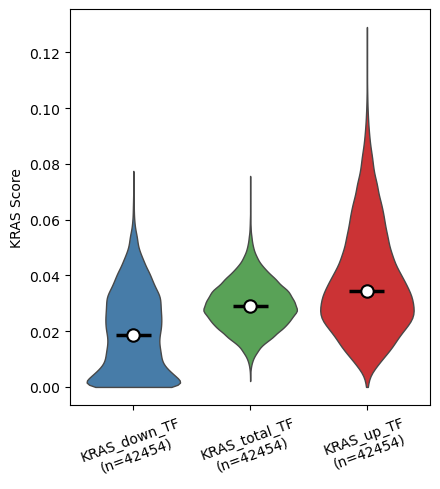

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_path = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)"

df = pd.read_csv(
    f"{base_path}/merge_KRAS.csv",
    index_col=0
)

target_cols = [
    "KRAS_down_TF",
    "KRAS_total_TF",
    "KRAS_up_TF"
]

palette = {
    "KRAS_down_TF": "#377eb8",
    "KRAS_total_TF": "#4daf4a",
    "KRAS_up_TF": "#e41a1c"
}

plot_df = df[target_cols].melt(
    var_name="Signature",
    value_name="Score"
)

plot_df = plot_df.dropna()

count_dict = (
    plot_df.groupby("Signature")
    .size()
    .to_dict()
)

median_dict = (
    plot_df.groupby("Signature")["Score"]
    .median()
    .to_dict()
)

x_labels = [
    f"{sig}\n(n={count_dict[sig]})"
    for sig in target_cols
]

plt.figure(figsize=(4.5, 5))

ax = sns.violinplot(
    data=plot_df,
    x="Signature",
    y="Score",
    hue="Signature",
    palette=palette,
    inner=None,
    linewidth=1,
    cut=0,
    legend=False
)

for i, sig in enumerate(target_cols):

    median_val = median_dict[sig]

    ax.scatter(
        i,
        median_val,
        s=80,
        color="white",
        edgecolor="black",
        linewidth=1.5,
        zorder=10
    )

    ax.hlines(
        median_val,
        i - 0.15,
        i + 0.15,
        colors="black",
        linewidth=2.5,
        zorder=9
    )

ax.set_xticklabels(
    x_labels,
    rotation=20
)

plt.xlabel("")
plt.ylabel("KRAS Score")

plt.tight_layout()
plt.show()